# Regresión lineal con sustitución no lineal   
Lugo Avalos Vanessa Aidee 6AM1

## Librerías
Se importan las librerías necesarias. Numpy permite la manipulación de datos como arreglos, pandas 
convierte datos a dataframe, matplotlib permite hacer las gráficas, y sklearn realiza el entrenamiento
del modelo de regresión y el calculo de las métricas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Conjunto de datos
Se establece el conjunto de datos donde se establece el precio de departamentos según el tamaño. De manera que, m2 indica el valor del tamaño del departamento, y precio el valor de este. 

In [2]:
m2 = [5.0, 5.2, 5.4, 5.61, 5.81, 6.02, 6.22, 6.42, 6.63, 6.83, 7.04, 7.24, 7.44, 7.65, 7.85, 8.06, 
      8.26, 8.46, 8.67, 8.87, 9.08, 9.28, 9.48, 9.69, 9.89, 10.10, 10.30, 10.51, 10.71, 10.91, 
      11.12, 11.32, 11.53, 11.73, 11.93, 12.14, 12.34, 12.55, 12.75, 12.95, 13.16, 13.36, 13.57, 
      13.77, 13.97, 14.18, 14.38, 14.59, 14.79, 15.0]

precio = [2.49, 1.92, 2.83, 3.87, 2.3, 2.51, 3.04, 4.0, 3.04, 4.35, 3.65, 3.98, 5.02, 3.22, 3.78, 
          5.33, 5.27, 7.01, 6.21, 6.14, 9.46, 8.22, 8.98, 7.97, 9.33, 10.49, 9.73, 11.78, 11.33, 12.18, 
          12.41, 15.42, 14.12, 13.65, 16.11, 14.66, 16.69, 15.13, 16.37, 18.52, 19.7, 19.77, 20.13,
          20.6, 20.09, 21.52, 22.45, 24.66, 24.64, 23.23]

## Conjunto de datos en un DataFrame
Se convierten los datos a un DataFrame de pandas para estructurar la información en forma de filas y columnas para que sea más sencillo manipularlos.

In [3]:
df = pd.DataFrame({'Tam_m2': m2, 'Precio': precio})

## Gráfica del conjunto de datos
Se hace la gráfica del conjunto de datos original donde cada punto (+) hace referencia a un departamento de acuerdo a su tamaño mostrado en el eje de las X, y a su precio mostrado en el eje de las Y.

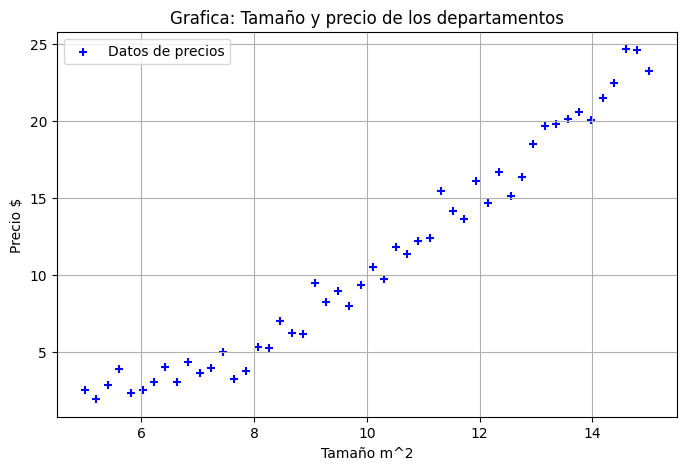

In [4]:
plt.figure(figsize = (8, 5))
plt.scatter(df['Tam_m2'], df['Precio'], label='Datos de precios', color= 'blue', marker='+')
plt.title('Grafica: Tamaño y precio de los departamentos')
plt.xlabel('Tamaño m^2')
plt.ylabel('Precio $')
plt.grid(True) #activar lineas de cuadricula
plt.legend() #etiqueta
plt.show()

## Realizar transformaciones logarítmicas
Se hace transformación logarítmica al precio y al tamaño del departamento. Este tipo de transformación sirve para comprimir el eje y realizar histogramas más sencillos de visualizar. Se trata de reemplazar el valor de cada variable por su logaritmo, de manera que reduce la asimetría de los datos originales.

In [5]:
df['Logaritmo_Precio'] = np.log(df['Precio'])
df['Logaritmo_Tam'] = np.log(df['Tam_m2'])

## Gráfica de transformación logarítmica sobre el precio

En este caso, se aplica la transformación lineal a la variable objetivo, es decir, al precio. De manera que ahora el eje de las Y, donde se expresa el precio, los valores ahora van de 0 a 3.5 aproximadamente, y no a 25.

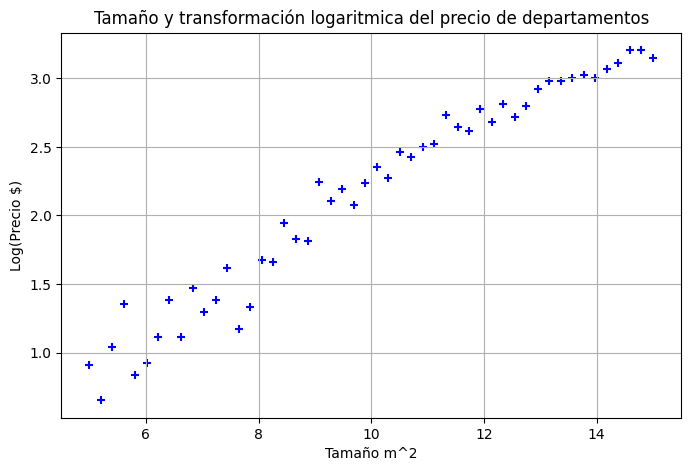

In [6]:
plt.figure(figsize = (8,5))
plt.scatter(df['Tam_m2'], df['Logaritmo_Precio'], color = 'blue', marker= '+')
plt.xlabel('Tamaño m^2')
plt.ylabel('Log(Precio $)')
plt.title('Tamaño y transformación logaritmica del precio de departamentos')
plt.grid(True)
plt.show()

## Gráfica de transformación logarítmica sobre el tamaño

Se grafican los datos una vez realizada la transformación logarítmica a la variable independiente, es decir, el tamaño de los departamentos, de manera que los valores del eje X ahora van de 0 a 6.8 en lugar de 0 a 14 como en los datos orignales.

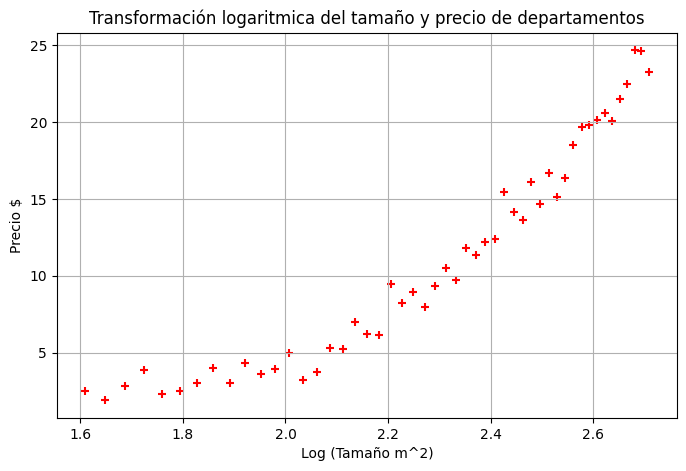

In [7]:
plt.figure(figsize = (8,5))
plt.scatter(df['Logaritmo_Tam'], df['Precio'], color = 'red', marker= '+')
plt.xlabel('Log (Tamaño m^2)')
plt.ylabel('Precio $')
plt.title('Transformación logaritmica del tamaño y precio de departamentos')
plt.grid(True)
plt.show()

## Gráfica de transformación logarítmica sobre el tamaño y precio 

Para esta gráfica se aplica transformación logarítmica a ambas variables, de manera que hay una reducción en ambos ejes, el eje de las X que representa la transformación del tamaño y el eje de las Y que representa la transformación aplicada al precio.

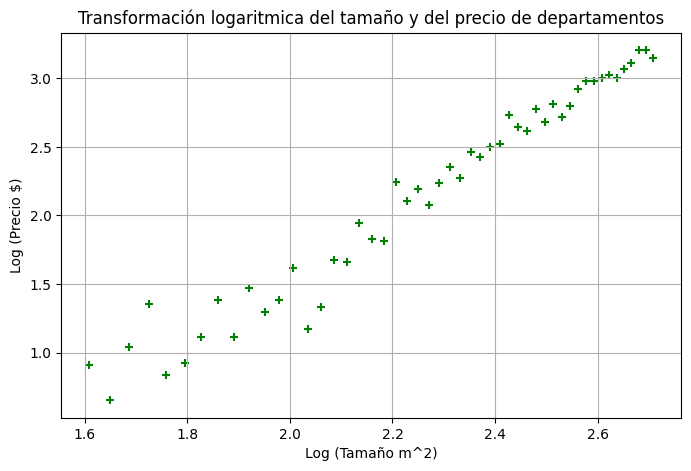

In [8]:
plt.figure(figsize = (8,5))
plt.scatter(df['Logaritmo_Tam'], df['Logaritmo_Precio'], color = 'green', marker= '+')
plt.xlabel('Log (Tamaño m^2)')
plt.ylabel('Log (Precio $)')
plt.title('Transformación logaritmica del tamaño y del precio de departamentos')
plt.grid(True)
plt.show()

## Función para realizar regresión lineal
Se realiza una función que aplica el modelo de regresión lineal de la librería de sklearn. Esta función recibe como parámetros a los datos de X, datos de Y, la cadena del título de la gráfica, la cadena del título del eje de las X de la gráfica y la cadena del título del eje de las Y.     
Primero, se transforma a la variable independiente a dos dimensiones para que pueda ser usado por sklearn, ya que el modelo busca recibir una matriz. Después, se llama a la clase de Regresión lineal, y se entrena con los valores de X y Y. Además, se calcula el valor de la Y predicha. Esto se hace con la formula:    
$$\hat{y} = \hat{b_0} + \hat{b_1} x$$    
Recordando que para el cálculo de los coeficientes se usan las formulas:
$$\hat{b_1} = \frac{\sum_{i =1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i =1}^n (x_i - \bar{x})^2}$$    
$$\hat{b_0} = \bar{y} - \hat{b_1}\bar{x}$$     

Luego, se calculan las métricas del modelo:   
MSE: Mean Squared Error (Error cuadrático medio).    
$$MSE = \frac{1}{n} \sum_{i = 1}^n (y_i - \hat{y_i})^2$$   

RMSE: Root Mean Squared Error (Raíz del error cuadrático medio).   
$$RMSE = \sqrt{MSE}$$     
MAE: Mean Absolute Error (Promedio del error absoluto medio).    
$$MAE = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y_i}|$$      
$R^2$: Coeficiente de determinación.    
$$R^2 = 1-\frac{\sum(\hat{y_i} - \bar{y_i})^2}{\sum (y_i - \bar{y_i})}$$    

Para después graficar los puntos de los datos dependiendo de lo que se reciba como parámetro, al igual que se grafica la recta de la regresión de acuerdo a los datos de Y y la Y predicha.   
Al final se imprime la ecuación de la recta considerando los valores de b0 y de b1, error cuadrático medio, raíz del error cuadrático medio, error absoluto medio, y el coeficiente de determinación.

In [9]:
def regresion_lineal(X, y, titulo, xlabel, ylabel):
    X = X.reshape(-1, 1)
    modelo = LinearRegression()
    modelo.fit(X, y)
    y_pred = modelo.predict(X)

    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    plt.figure(figsize = (8, 5))
    plt.scatter(X, y, color = 'blue', marker = '+')
    plt.plot(X, y_pred, color = 'red', linewidth = 2, label = 'Regresion')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(titulo)
    plt.grid(True)
    plt.legend()
    plt.show()

    print(titulo)
    print(f'Ecuacion: y = {modelo.intercept_} + {modelo.coef_[0]}')
    print(f'Error Cuadrático Medio: {mse}')
    print(f'Raíz del Error Cuadrático Medio: {rmse}')
    print(f'Error Absoluto Medio: {mae}')
    print(f'Coeficiente de Determinación R^2: {r2}')


## Gráfica con regresión lineal de transformación logarítmica del precio vs tamaño original 

Cuando se aplica transformación logarítmica a la variable objetivo, se dice que se trata de una "Regresión de nivel logarítmico". La gráfica muestra en el eje de las Y a la transformación del precio, y en el eje X a los valores originales del tamaño. Así mismo, se hace regresión con las X modificadas, y la recta resultante se grafica de color rojo.

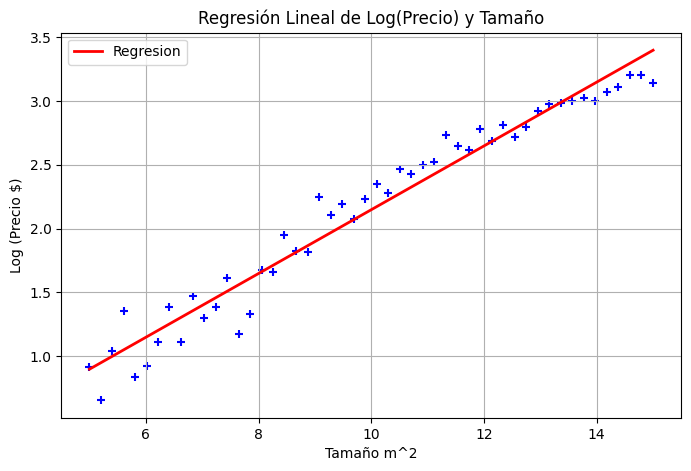

Regresión Lineal de Log(Precio) y Tamaño
Ecuacion: y = -0.35606866807774207 + 0.2503955568248659
Error Cuadrático Medio: 0.02460183522265515
Raíz del Error Cuadrático Medio: 0.15684972178061124
Error Absoluto Medio: 0.12567422271640621
Coeficiente de Determinación R^2: 0.9567151097553139


In [10]:
regresion_lineal(df['Tam_m2'].values, df['Logaritmo_Precio'].values, 'Regresión Lineal de Log(Precio) y Tamaño',
                 'Tamaño m^2', 'Log (Precio $)')

## Gráfica con regresión lineal de precio original vs  transformación logarítmica del tamaño

En este caso se aplica regresión lineal usando los datos originales de la variable dependiente y los datos transformados de la variable independiente.   
Cuando se aplica transformación logarítmica a una o más de las variables independientes, se tiene una "regresión logarítmica de nivel"   
Se manda a llamar a la función de regresión lineal y se escriben los parametros, donde X son los valores de la transformacion logaritmica del tamaño, Y son los valores originales de precio, y se escribe el titulo de la grafica, el titulo del eje X (transformacion del tamaño) y el titulo del eje Y (precio). Tambien se grafica de color rojo la recta de la regresion resultante.

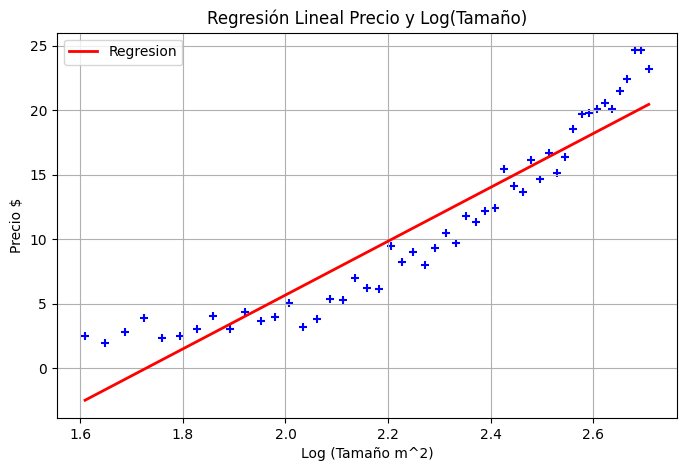

Regresión Lineal Precio y Log(Tamaño)
Ecuacion: y = -36.12819095213517 + 20.894901085512494
Error Cuadrático Medio: 5.377452781776269
Raíz del Error Cuadrático Medio: 2.3189335440620695
Error Absoluto Medio: 2.0024313725155465
Coeficiente de Determinación R^2: 0.8896627303883703


In [11]:
regresion_lineal(df['Logaritmo_Tam'].values, df['Precio'].values, 'Regresión Lineal Precio y Log(Tamaño)',
                 'Log (Tamaño m^2)', 'Precio $')

## Gráfica con regresión lineal de transformación logarítmica del precio vs transformación logarítmica del tamaño

"Regresión registro-registro o log-log" sucede cuando se aplica transformación logaritmica a las variables dependientes y a las variables independientes. 

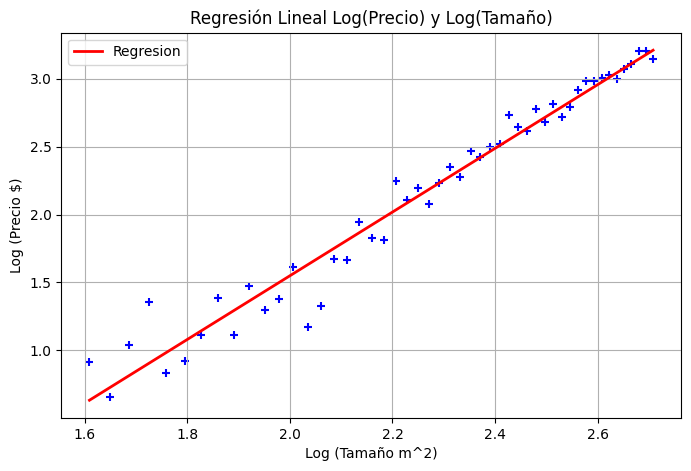

Regresión Lineal Log(Precio) y Log(Tamaño)
Ecuacion: y = -3.145019454345573 + 2.346843677968528
Error Cuadrático Medio: 0.021395075999941945
Raíz del Error Cuadrático Medio: 0.1462705575293331
Error Absoluto Medio: 0.10367031632521428
Coeficiente de Determinación R^2: 0.9623571368537011


In [12]:
regresion_lineal(df['Logaritmo_Tam'].values, df['Logaritmo_Precio'].values, 
                 'Regresión Lineal Log(Precio) y Log(Tamaño)', 'Log (Tamaño m^2)', 'Log (Precio $)')

## Conclusiones
Con base en los resultados de las métricas después de aplicar regresión lineal con transformación logarítmica aplicada de tres maneras distintas, se concluye que, el modelo que mejor representa los datos es en el que se aplica la transformación a ambas variables, pues se tiene un coeficiente de determinación más alto con un valor de 0.9624 lo cual indica que el modelo explica un 96.24% de la variabilidad de los datos. Además, los valores para el error cuadrático medio, raíz del error cuadrático medio, error absoluto medio son más pequeños en comparacióncon los primeros dos modelos. 

## Documentación

### Gráfica de histogramas

Es un gráfico estadístico que representa la distribución de los datos a través de barras trazadas, de manera que cada barra representa una categoría o intervalo. La altura de la barra representa la frecuencia en que se presenta este dato, de manera que se pueden observar patrones en datos sin procesar. El eje de las X representa los intervalos, el eje de las Y representa la frecuencia de los datos, que puede ser absoluta o relativa. Para hacer un histograma se requiere de:    
1. Determinar el número de intervalos o clases: Se puede usar una tabla guía, calcular la raíz cuadrada de la cantidad de datos, o usar el método de Sturges el cual esta dado por:
$$k = 1 + log_2N$$
2. Calcular la amplitud del intervalo: Se hace con la siguiente formula:
$$ w = \frac{NumeroMayor-NumeroMenor}{Intervalos}$$
3. Calcular las ocurrencias: Se hace el conteo de cada ocurrencia en cada intervalo.

### Transformación Box-Cox

Se encarga de transformar las variables dependientes que no siguen una distribución normal a datos que sí, lo cual permite realizar una mayor cantidad de pruebas. La primera muestra funciona solo para valores psoitivos, mientras que la segunda fórmula acepta valores negativos:
$$y(\lambda) = \begin{cases} 
\frac{y^\lambda - 1}{\lambda}, & \text{if } \lambda \neq 0; \\ 
\log y, & \text{if } \lambda = 0. 
\end{cases}$$
$$y(\boldsymbol{\lambda}) = \begin{cases} 
\frac{(y + \lambda_2)^{\lambda_1} - 1}{\lambda_1}, & \text{if } \lambda_1 \neq 0; \\ 
\log(y + \lambda_2), & \text{if } \lambda_1 = 0. 
\end{cases}$$
Donde el valor de lambda tiene valores de -5 a 5, se hacen distintas pruebas y el mejor se considera como el óptimo.    
Se debe considerar que esta transformación es sensible a outliers.

### Transformación Recíproca

Se define como la transformación de x a 1/x, de manera que invierte el orden de los valores manteniendo el mismo signo, es útil para abordar la heterocedasticidad, donde la variabilidad de los errores en un modelo de regresión difiere entre los valores de una variable independiente, y para transformar distribuciones asimétricas en distribuciones más simétricas.

## Referencias
Feature-engine. (s.f.). ReciprocalTransformer. https://feature-engine.trainindata.com/en/1.8.x/user_guide/transformation/ReciprocalTransformer.html     
Saw, K. (2020). Log Transformation: Purpose and Interpretation. Medium. https://medium.com/@kyawsawhtoon/log-transformation-purpose-and-interpretation-9444b4b049c9     
Jaspersoft. (s.f.). ¿Qué es un gráfico de histograma? Cloud Software Group. https://www.jaspersoft.com/es/articles/what-is-a-histogram-chart      
GeeksforGeeks. (2023). Box-Cox Transformation using Python. https://www.geeksforgeeks.org/python/box-cox-transformation-using-python/    